In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("../../../../../Data/Iris.csv")
df.drop(columns=['Id'],inplace=True)

encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
df = df[df['Species'] != 0]
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
df = df.sample( df.shape[0] )   # shffle

df_train = df.iloc[:60, :]
df_individual_test = df.iloc[60:80, :].sample(5)
df_voting_test = df.iloc[80:, :].sample(5)

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
def X_y_split(df):
    return df.iloc[:,:-1], df.iloc[:,-1]

In [6]:
X_individual_testing, y_individual_testing = X_y_split(df_individual_test)

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

def evaluateModelTree(model, X_train, y_train, training_cols):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_individual_testing[training_cols])
    print("Accuracy Score:", accuracy_score(y_individual_testing, y_pred)) 
    plot_tree(
        model,
        feature_names=X_train.columns,
        class_names=[str(int(cls)) for cls in np.unique(y_train)],
        filled=True,
        rounded=True,
        fontsize=10
    )
    
    plt.show()
    plot_decision_regions(X_train.values, y_train.values, clf=model, legend=2)

### Tree 1 

Accuracy Score: 0.6


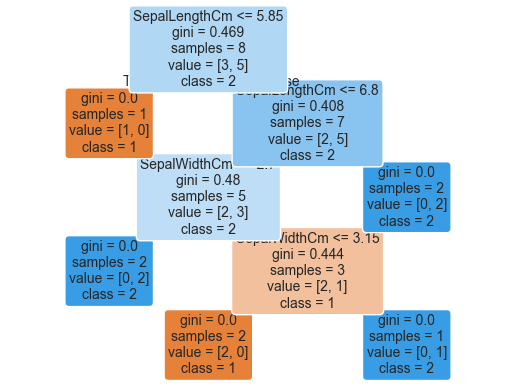

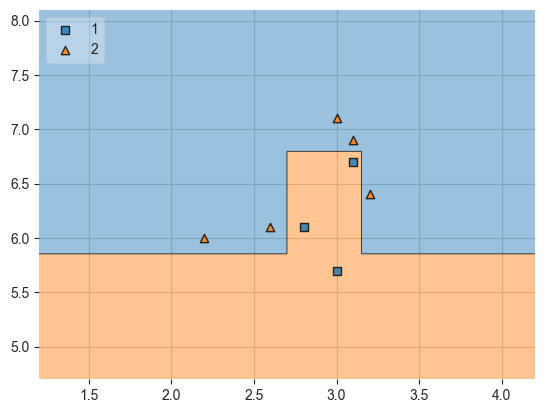

In [9]:
from sklearn.tree import DecisionTreeClassifier

X_train1, ytrain1= X_y_split(df_train)

X_train1 = X_train1.sample(2, axis=1, replace=False).sample(8, axis=0, replace=False)

training1_cols = X_train1.columns
ytrain1_subset = ytrain1.loc[X_train1.index]

dt1 = DecisionTreeClassifier()
evaluateModelTree(dt1, X_train1, ytrain1_subset, training1_cols)

### Tree2

Accuracy Score: 0.8


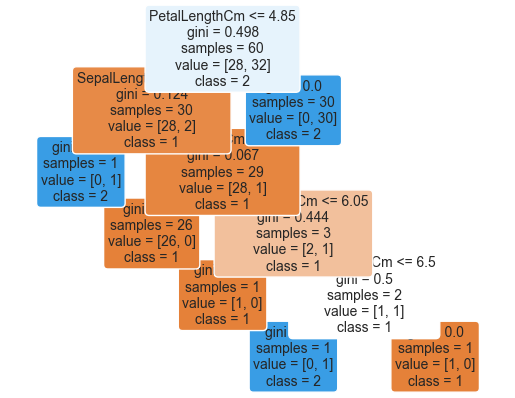

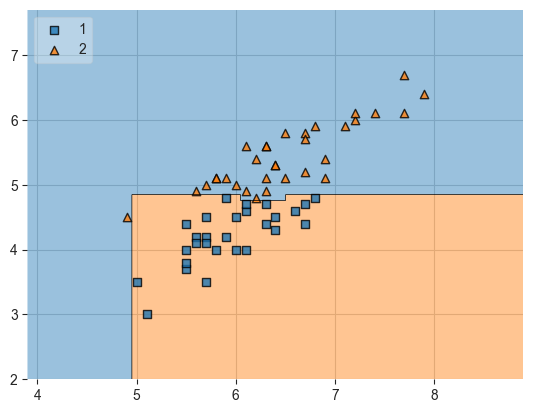

In [10]:
X_train2, ytrain2= X_y_split(df_train)

X_train2 = X_train2.sample(2, axis=1, replace=False)
training2_cols = X_train2.columns

ytrain2_subset = ytrain2.loc[X_train2.index]

dt2 = DecisionTreeClassifier()
evaluateModelTree(dt2, X_train2, ytrain2_subset, training2_cols)

### Tree3

Accuracy Score: 0.4


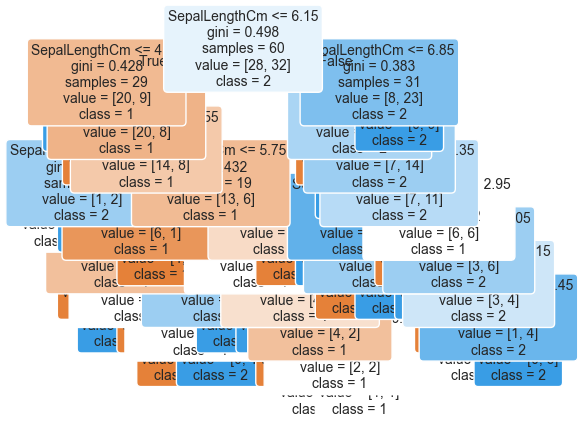

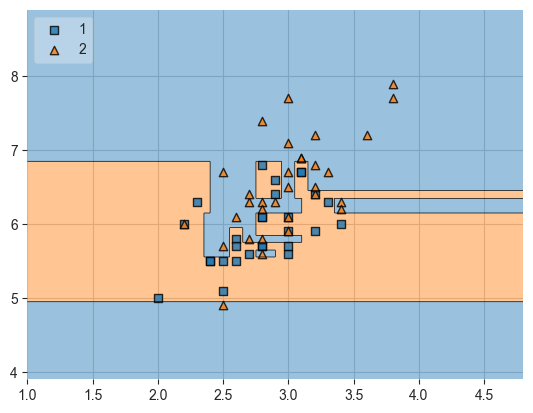

In [11]:
X_train3, ytrain3= X_y_split(df_train)

X_train3 = X_train3.sample(2, axis=1, replace=False)
training3_cols = X_train3.columns
ytrain3_subset = ytrain3.loc[X_train3.index]

dt3 = DecisionTreeClassifier()
evaluateModelTree(dt3, X_train3, ytrain3_subset, training3_cols)

In [12]:
df_voting_test

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
64,5.6,2.9,3.6,1.3,1
57,4.9,2.4,3.3,1.0,1
75,6.6,3.0,4.4,1.4,1
138,6.0,3.0,4.8,1.8,2
82,5.8,2.7,3.9,1.2,1
